In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO(r"/content/lp_detect.pt")
ocr = YOLO(r"/content/char_detect.pt")


image 1/1 /content/bien-so-xe-trang.jpg: 384x640 1 License_Plate, 534.8ms
Speed: 18.7ms preprocess, 534.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


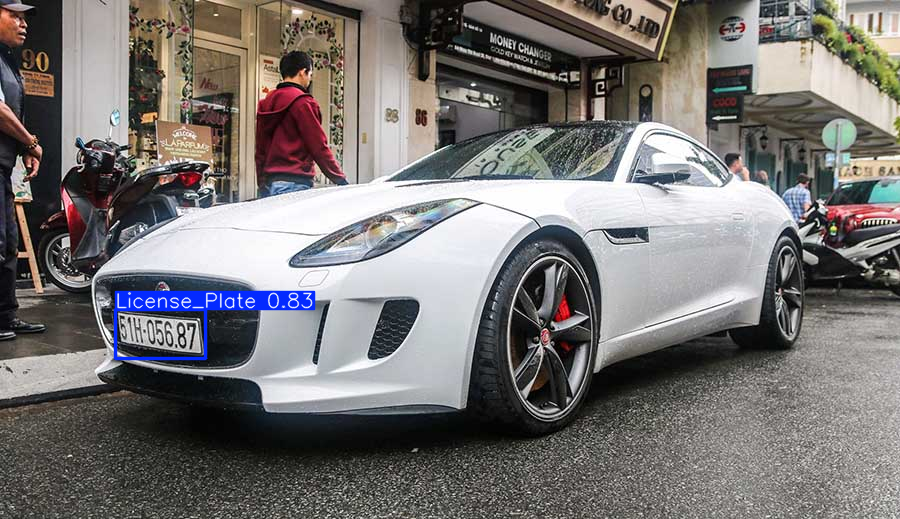

In [ ]:
img_path = ["/content/bien-so-xe-trang.jpg"]

for i in img_path:
  results = model(i, imgsz=640, conf=0.6)
  results[0].show()

In [ ]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
import numpy as np
def getLPText(plate_crop, plate_ocr):
    """
    Extracts text from a license plate using OCR after correcting skew.

    Args:
    - plate_crop (numpy array): Cropped license plate image.
    - plate_ocr (object): OCR model
    Returns:
    - final_text (str): Detected license plate text.
    """
    # Run OCR
    text_plate = plate_ocr(plate_crop, imgsz=640, conf=0.5, verbose=False)

    plt.imshow(text_plate[0].plot())
    plt.show()

    ocr_pre = text_plate[0]
    id2char = plate_ocr.names
    boxes = ocr_pre.boxes

    cls_ids = boxes.cls.cpu().numpy().astype(int)
    box_coords = boxes.xyxy.cpu().numpy()
    combined = list(zip(box_coords, cls_ids))

    # Cluster based on vertical (Y) position
    y_centers = np.array([[((box[1] + box[3]) / 2)] for box, _ in combined])
    n_clusters = 2 if len(combined) >= 6 else 1

    kmeans = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(y_centers)

    # Group by row clusters
    rows = [[] for _ in range(n_clusters)]
    for (box, cls_id), label in zip(combined, labels):
        x1 = box[0]
        rows[label].append((x1, cls_id))

    # Sort rows top-to-bottom
    row_avg_y = [np.mean([y_centers[i][0] for i in range(len(labels)) if labels[i] == r]) for r in range(n_clusters)]
    sorted_rows = [row for _, row in sorted(zip(row_avg_y, rows), key=lambda x: x[0])]

    # Sort each row left-to-right
    detected_text = []
    for row in sorted_rows:
        row.sort(key=lambda item: item[0])  # sort by x
        row_text = ''.join(id2char[cls_id] for _, cls_id in row)
        detected_text.append(row_text)

    final_text = ''.join(detected_text)
    return final_text

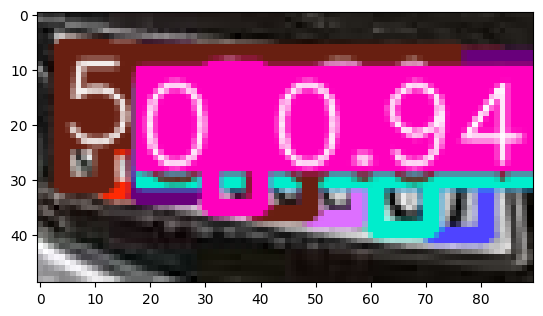

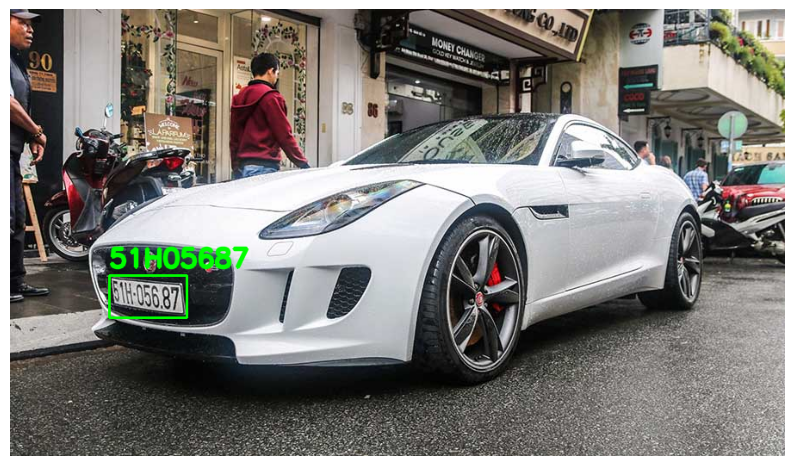

In [ ]:
for i in img_path:
    img = cv2.imread(i) # Read the image once here
    if img is None:
        print(f"Error: Could not read image {i}. Skipping.")
        continue

    results = model(img, imgsz=640,conf=0.6, verbose=False) # Pass the image directly to the model

    img_with_boxes_and_text = img.copy()

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = img[y1:y2, x1:x2]

            # Read LP
            final_lp = getLPText(plate_crop, ocr)

            # Draw the bounding box
            cv2.rectangle(img_with_boxes_and_text, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Put the detected text on the image
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 1
            font_thickness = 3
            text_color = (0, 255, 0)

            # Calculate text size to position it above the box
            (text_width, text_height), baseline = cv2.getTextSize(final_lp, font, font_scale, font_thickness)
            text_x = x1
            text_y = y1 - 10 if y1 - 10 > text_height else y1 + text_height + 5

            cv2.putText(img_with_boxes_and_text, final_lp, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Display the image with boxes and text
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_with_boxes_and_text, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()